In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [4]:
insurance = pd.read_csv('./insurance.csv')

In [5]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
X = insurance.drop(columns=["charges","region"])
y = insurance["charges"]

In [7]:
X["smoker"] = X["smoker"].map({"yes":1,"no":0})
X["sex"] = X["sex"].map({"female":1,"male":0}) 

In [8]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [9]:
X.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [11]:
lr = LinearRegression()

In [12]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred = lr.predict(X_test)

In [14]:
r2_score(y_pred,y_test)

0.7054413633224745

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# learn scaling from train
X_train_scaled = scaler.fit_transform(X_train)
# apply same scaling to test
X_test_scaled = scaler.transform(X_test)

- Interview-level answer (short version)
- Why fit_transform on train and transform on test?
- Because train data is used to calculate scaling parameters (mean, std), and test data must use same parameters to maintain
  consistency and avoid data leakage.

In [31]:
class GDRegressor:
    def __init__(self,learing_rate=0.00001,epochs=1000):
        self.lr = learing_rate
        self.epochs = epochs
        self.coef_ = None ## x (m)
        self.intercept_ = None ## bita (b)
        self.losses = []
    
    def fit(self,X_train,y_train):
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        self.losses = []

        for _ in range(self.epochs):
            y_hat = np.dot(X_train,self.coef_) + self.intercept_ 

            loss = np.mean((y_train - y_hat)**2)  ##  calculate loss (MSE)
            self.losses.append(loss)
        
            intercept_der = -2 * np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ - self.lr * intercept_der

            coef_der = -2 * np.dot(X_train.T,(y_train - y_hat)) / X_train.shape[0]
            self.coef_ = self.coef_ - self.lr * coef_der
        print(self.intercept_,self.coef_)
         
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [32]:
gd = GDRegressor(learing_rate=0.1,epochs=100)

In [35]:
gd.fit(X_train_scaled, y_train)

13346.08973364584 [3.61628727e+03 3.97471476e+00 1.97848618e+03 5.19291487e+02
 9.55960268e+03]


In [36]:
X_train_scaled 

array([[ 0.47222651,  1.0246016 , -1.75652513,  0.73433626, -0.50874702],
       [ 0.54331294,  1.0246016 , -1.03308239, -0.91119211, -0.50874702],
       [ 0.8987451 ,  1.0246016 , -0.94368672, -0.91119211, -0.50874702],
       ...,
       [ 1.3252637 , -0.97598911, -0.89153925, -0.91119211, -0.50874702],
       [-0.16755139,  1.0246016 ,  2.82086429,  0.73433626,  1.96561348],
       [ 1.1120044 , -0.97598911, -0.10932713, -0.91119211, -0.50874702]],
      shape=(1070, 5))

In [37]:
y_pred = gd.predict(X_test_scaled)

In [38]:
r2_score(y_test,y_pred)

0.7811302112711734

In [39]:
r2_score(y_pred,y_test)

0.7054413623838731

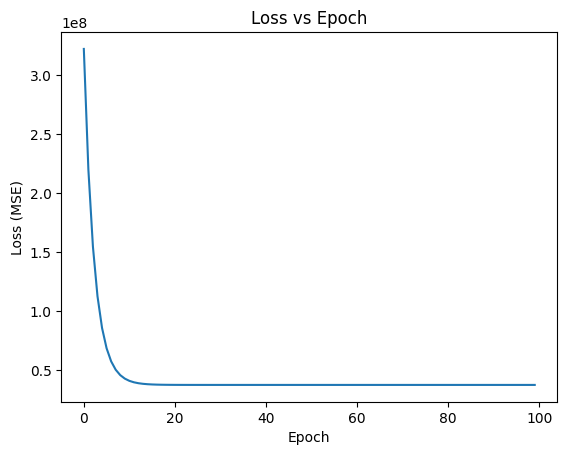

In [40]:
plt.plot(gd.losses)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epoch")
plt.show()